# 01 - A2C su CartPole

Questo notebook valida una implementazione essenziale di Advantage Actor-Critic su `CartPole-v1`.

CartPole viene usato come ambiente di controllo: lo stato ha dimensione ridotta, le azioni sono discrete e il reward coincide con la durata dell'episodio. Il valore massimo per episodio e' quindi 500.

## Setup

Carico configurazione, moduli riutilizzabili e device. L'esecuzione usa CPU.

In [1]:
from pathlib import Path
import sys

import gymnasium as gym
import matplotlib.pyplot as plt
import pandas as pd
import torch
import yaml
from torch.optim import Adam

current_dir = Path.cwd().resolve()
for candidate in [current_dir, *current_dir.parents]:
    if (candidate / "DLA_LAB3" / "src").exists():
        project_root = candidate
        break
else:
    raise RuntimeError("Eseguire il notebook dalla repository Deep_Learning_Laboratories.")

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from DLA_LAB3.src.a2c import train_a2c, train_vectorized_a2c
from DLA_LAB3.src.evaluation import evaluate_policy, render_policy
from DLA_LAB3.src.networks import PolicyNetwork, ValueNetwork
from DLA_LAB3.src.plotting import plot_seed_eval_curves
from DLA_LAB3.src.utils import get_device, make_vector_env, restore_model_state, seed_environment, set_seed

In [2]:
config_path = project_root / "DLA_LAB3" / "exercise_3_1_a2c" / "config_cartpole.yaml"
with config_path.open("r", encoding="utf-8") as file:
    raw_config = yaml.safe_load(file)

CONFIG = {
    "environment_name": raw_config["environment"]["name"],
    "seeds": raw_config["training"]["seeds"],
    "num_episodes": raw_config["training"]["num_episodes"],
    "max_steps": raw_config["environment"]["max_steps"],
    "gamma": raw_config["training"]["gamma"],
    "learning_rate": raw_config["training"]["learning_rate"],
    "hidden_dim": raw_config["training"]["hidden_dim"],
    "rollout_steps": raw_config["training"]["rollout_steps"],
    "vectorized": raw_config["training"].get("vectorized", False),
    "num_envs": raw_config["training"].get("num_envs", 1),
    "vector_env_type": raw_config["training"].get("vector_env_type", "sync"),
    "value_loss_weight": raw_config["training"]["value_loss_weight"],
    "standardize_advantages": raw_config["training"]["standardize_advantages"],
    "standardize_critic_targets": raw_config["training"].get("standardize_critic_targets", False),
    "entropy_weight": raw_config["training"]["entropy_weight"],
    "evaluation_episodes": raw_config["evaluation"]["num_episodes"],
    "eval_every_n": raw_config["evaluation"]["eval_every_n"],
    "eval_episodes_m": raw_config["evaluation"]["eval_episodes_m"],
}

set_seed(CONFIG["seeds"][0])
device = get_device(force_cpu=raw_config["training"]["force_cpu"])
device

device(type='cpu')

## Ambiente CartPole

In [3]:
env = gym.make(CONFIG["environment_name"])
observation, info = seed_environment(env, CONFIG["seeds"][0])

observation_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

print("Observation iniziale:", observation)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Observation dim:", observation_dim)
print("Action dim:", action_dim)

Observation iniziale: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Observation dim: 4
Action dim: 2


## Training per seed

Addestro un agente indipendente per ogni seed configurato. Ogni run crea una nuova actor network, una nuova critic network e un nuovo ottimizzatore.

L'aggiornamento A2C usa rollout brevi con bootstrap di `V(s)`. Non uso early stopping o scheduler; salvo pero' in memoria il miglior checkpoint osservato durante la valutazione periodica e lo ripristino prima della valutazione finale.

In [4]:
# Manteniamo separati risultati e modelli per confrontare i seed a parita' di configurazione.
training_results = {}
trained_actors = {}
summary_rows = []

for seed in CONFIG["seeds"]:
    print(f"Run seed {seed}")
    set_seed(seed)

    # La stessa pipeline supporta sia un ambiente singolo sia raccolta sincrona parallela.
    use_vectorized_training = CONFIG["vectorized"] and CONFIG["num_envs"] > 1
    if use_vectorized_training:
        train_env = make_vector_env(
            environment_name=CONFIG["environment_name"],
            seed=seed,
            num_envs=CONFIG["num_envs"],
            vector_env_type=CONFIG["vector_env_type"],
        )
    else:
        train_env = gym.make(CONFIG["environment_name"])
        seed_environment(train_env, seed)

    actor = PolicyNetwork(observation_dim, action_dim, CONFIG["hidden_dim"]).to(device)
    critic = ValueNetwork(observation_dim, CONFIG["hidden_dim"]).to(device)
    optimizer = Adam(
        list(actor.parameters()) + list(critic.parameters()),
        lr=CONFIG["learning_rate"],
    )

    eval_env_inter = gym.make(CONFIG["environment_name"])
    seed_environment(eval_env_inter, seed)

    if use_vectorized_training:
        training_result = train_vectorized_a2c(
            envs=train_env,
            actor=actor,
            critic=critic,
            optimizer=optimizer,
            device=device,
            num_episodes=CONFIG["num_episodes"],
            gamma=CONFIG["gamma"],
            max_steps=CONFIG["max_steps"],
            rollout_steps=CONFIG["rollout_steps"],
            value_loss_weight=CONFIG["value_loss_weight"],
            standardize_advantages=CONFIG["standardize_advantages"],
            standardize_critic_targets=CONFIG["standardize_critic_targets"],
            entropy_weight=CONFIG["entropy_weight"],
            eval_env=eval_env_inter,
            eval_every_n=CONFIG["eval_every_n"],
            eval_episodes_m=CONFIG["eval_episodes_m"],
        )
    else:
        training_result = train_a2c(
            env=train_env,
            actor=actor,
            critic=critic,
            optimizer=optimizer,
            device=device,
            num_episodes=CONFIG["num_episodes"],
            gamma=CONFIG["gamma"],
            max_steps=CONFIG["max_steps"],
            rollout_steps=CONFIG["rollout_steps"],
            value_loss_weight=CONFIG["value_loss_weight"],
            standardize_advantages=CONFIG["standardize_advantages"],
            standardize_critic_targets=CONFIG["standardize_critic_targets"],
            entropy_weight=CONFIG["entropy_weight"],
            eval_env=eval_env_inter,
            eval_every_n=CONFIG["eval_every_n"],
            eval_episodes_m=CONFIG["eval_episodes_m"],
        )
    train_env.close()
    eval_env_inter.close()

    # Actor e critic devono provenire dallo stesso checkpoint di valutazione.
    restore_model_state(actor, training_result.best_actor_state)
    restore_model_state(critic, training_result.best_critic_state)

    eval_env = gym.make(CONFIG["environment_name"])
    seed_environment(eval_env, seed)
    evaluation = evaluate_policy(
        env=eval_env,
        policy=actor,
        device=device,
        num_episodes=CONFIG["evaluation_episodes"],
        max_steps=CONFIG["max_steps"],
        deterministic=True,
    )
    eval_env.close()

    training_results[seed] = training_result
    trained_actors[seed] = actor
    row = {
        "Seed": seed,
        "Final Train Reward": round(training_result.episode_rewards[-1], 1),
        "Best Train Reward": round(max(training_result.episode_rewards), 1),
        "Eval Mean Reward": round(evaluation["mean_reward"], 1),
        "Eval Min Reward": round(evaluation["min_reward"], 1),
        "Eval Max Reward": round(evaluation["max_reward"], 1),
        "Eval Mean Length": round(evaluation["mean_length"], 1),
        "Best Checkpoint Episode": training_result.best_eval_episode,
        "Best Checkpoint Reward": round(training_result.best_eval_mean_reward, 1),
    }
    summary_rows.append(row)
    print(row)

results_table = pd.DataFrame(summary_rows)
best_seed = int(results_table.sort_values("Eval Mean Reward", ascending=False).iloc[0]["Seed"])
best_actor = trained_actors[best_seed]

display(results_table.sort_values("Eval Mean Reward", ascending=False).reset_index(drop=True))
print("Seed migliore in valutazione:", best_seed)

Run seed 42
{'Seed': 42, 'Final Train Reward': 110.0, 'Best Train Reward': 500.0, 'Eval Mean Reward': 500.0, 'Eval Min Reward': 500.0, 'Eval Max Reward': 500.0, 'Eval Mean Length': 500.0, 'Best Checkpoint Episode': 300, 'Best Checkpoint Reward': 500.0}
Run seed 123
{'Seed': 123, 'Final Train Reward': 19.0, 'Best Train Reward': 176.0, 'Eval Mean Reward': 142.4, 'Eval Min Reward': 135.0, 'Eval Max Reward': 149.0, 'Eval Mean Length': 142.4, 'Best Checkpoint Episode': 540, 'Best Checkpoint Reward': 142.6}
Run seed 314
{'Seed': 314, 'Final Train Reward': 305.0, 'Best Train Reward': 500.0, 'Eval Mean Reward': 500.0, 'Eval Min Reward': 500.0, 'Eval Max Reward': 500.0, 'Eval Mean Length': 500.0, 'Best Checkpoint Episode': 180, 'Best Checkpoint Reward': 500.0}
Run seed 2024
{'Seed': 2024, 'Final Train Reward': 115.0, 'Best Train Reward': 500.0, 'Eval Mean Reward': 500.0, 'Eval Min Reward': 500.0, 'Eval Max Reward': 500.0, 'Eval Mean Length': 500.0, 'Best Checkpoint Episode': 340, 'Best Checkpoi

,Seed,Final Train Reward,Best Train Reward,Eval Mean Reward,Eval Min Reward,Eval Max Reward,Eval Mean Length,Best Checkpoint Episode,Best Checkpoint Reward
0,42,110.0,500.0,500.0,500.0,500.0,500.0,300,500.0
1,314,305.0,500.0,500.0,500.0,500.0,500.0,180,500.0
2,2024,115.0,500.0,500.0,500.0,500.0,500.0,340,500.0
3,9001,90.0,500.0,368.7,325.0,412.0,368.7,420,387.0
4,123,19.0,176.0,142.4,135.0,149.0,142.4,540,142.6


Seed migliore in valutazione: 42


## Curve di valutazione periodica

La curva mostra la valutazione deterministica eseguita a intervalli regolari. Ogni punto e' la media su episodi di valutazione, senza media mobile sui reward di training.

Il comportamento tra seed puo' essere molto diverso: A2C e' sensibile alla traiettoria di training e per questo la valutazione finale usa il miglior checkpoint osservato durante la valutazione periodica.

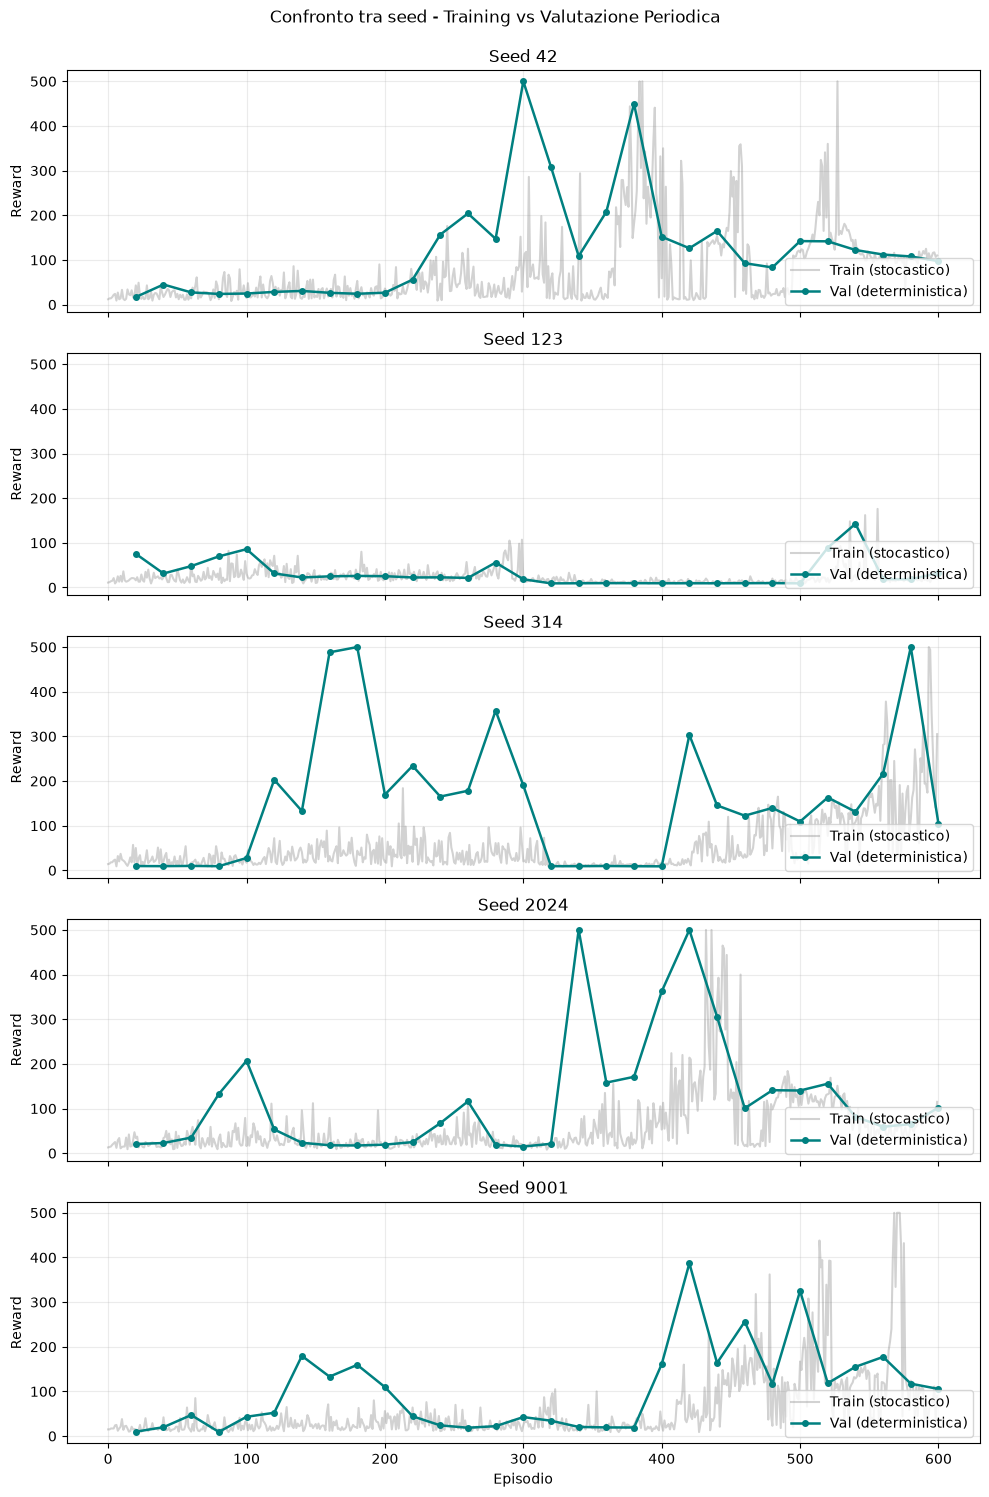

In [5]:
plot_seed_eval_curves(
    {
        seed: {
            "train_rewards": result.episode_rewards,
            "eval_intervals": result.eval_episodes,
            "eval_rewards": result.eval_mean_rewards,
        }
        for seed, result in training_results.items()
    }
)

## Analisi della Loss A2C

La loss actor e' il termine di policy gradient pesato dall'advantage, mentre la loss critic e' l'errore quadratico tra $V(s)$ e il target bootstrap n-step. Le curve sono mostrate separatamente per seed, un punto per ogni aggiornamento (rollout raccolto).

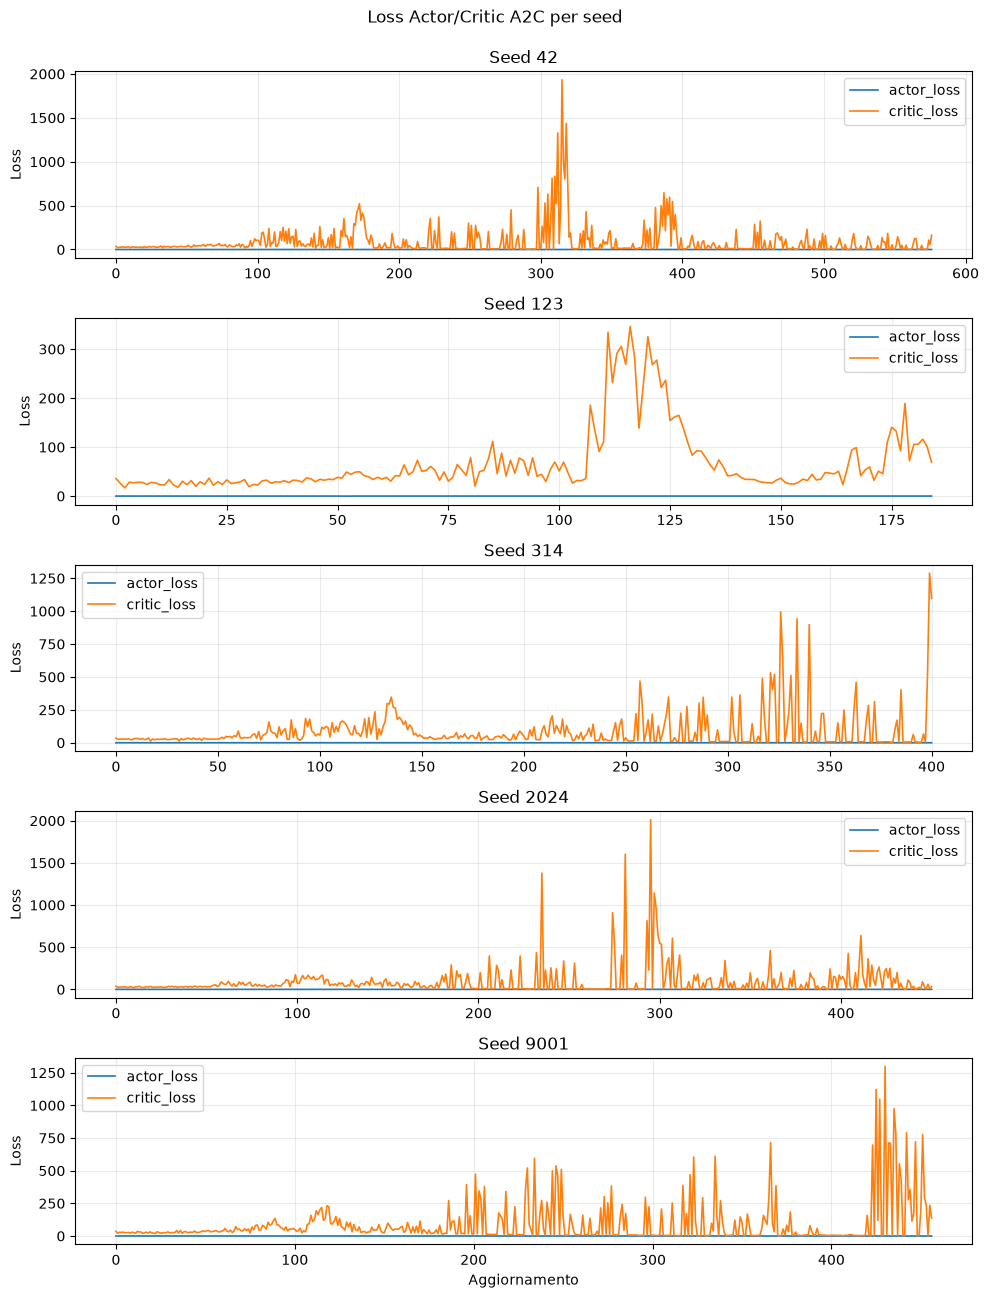

In [6]:
fig, axes = plt.subplots(
    len(training_results),
    1,
    figsize=(10, 2.6 * len(training_results)),
    sharex=False,
)

if len(training_results) == 1:
    axes = [axes]

for axis, (seed, result) in zip(axes, training_results.items()):
    axis.plot(result.actor_losses, linewidth=1.2, color="tab:blue", label="actor_loss")
    axis.plot(result.critic_losses, linewidth=1.2, color="tab:orange", label="critic_loss")
    axis.set_title(f"Seed {seed}")
    axis.set_ylabel("Loss")
    axis.legend()
    axis.grid(alpha=0.25)

axes[-1].set_xlabel("Aggiornamento")
fig.suptitle("Loss Actor/Critic A2C per seed", y=0.995)
fig.tight_layout()
plt.show()

### Osservazioni

- Verifico che `standardize_advantages` normalizza solo l'advantage usata dall'actor, non i ritorni bootstrap passati al critic (`a2c_loss`/`vectorized_a2c_loss` in `src/a2c.py`).
- Rilevo che il critic loss resta quindi su scala grezza: con `gamma=0.99` il valore atteso di uno stato arriva fino a ~100, e i picchi in figura coincidono con i salti di reward tra episodi corti ed episodi quasi-perfetti.
- Considero questa variabilita' una caratteristica di A2C senza normalizzazione dei ritorni.

## Risultati aggregati

La tabella aggregata riassume reward medio e lunghezza media sui seed configurati. In CartPole questi due valori coincidono numericamente perche' il reward cresce di 1 a ogni step.

A2C puo' raggiungere reward elevati su CartPole, ma resta sensibile al seed e alla stabilita' della traiettoria di training.

In [7]:
aggregated_table = results_table.agg(
    {
        "Eval Mean Reward": ["mean", "std", "min", "max"],
        "Eval Mean Length": ["mean", "std", "min", "max"],
    }
).round(1)

display(aggregated_table)

,Eval Mean Reward,Eval Mean Length
mean,402.2,402.2
std,156.0,156.0
min,142.4,142.4
max,500.0,500.0


## Visualizzazione real time

Renderizzo la policy con migliore reward medio di valutazione. Il modello renderizzato e' il miglior checkpoint ripristinato per il seed selezionato.

In [8]:
render_rewards = render_policy(
    environment_name=CONFIG["environment_name"],
    policy=best_actor,
    device=device,
    num_episodes=3,
    max_steps=CONFIG["max_steps"],
    deterministic=True,
    frame_delay=0.02,
)

print("Reward episodi renderizzati:", render_rewards)

Reward episodi renderizzati: [500.0, 500.0, 500.0]


In [9]:
env.close()